# ML3_Validation

## Задание 1. Answer the questions from the introduction

**i. What is leave-one-out? Provide limitations and strengths**

Метод leave-one-out - частный случай метода k-Fold (т.к. k=N), простая кросс-валидация, где каждый обучающий набор создается путем взятия всех образцов кроме одного, а тестовый набор тем временем создается как раз из этого оставшегося образца. Для n элементов имеем n различных обучающих наборов и n тестовых наборов. Модель обучается на n-1 объектах и делает предсказание для тестового объекта.

Плюсы: на каждом шаге модель обучается практически на всем массиве данных (N-1), что снижает смещение оценки качества. Хорошо подходит для малых датасетов.

Минусы: может быть ресурсоемко для больших данных в наборе. Чувствителен к выбросам

Источники:

- https://scikit-learn.ru/stable/modules/cross_validation.html
- https://learningdatascience.ru/%D0%A0%D0%A3/%D0%9A/%D0%9A%D1%80%D0%BE%D1%81%D1%81-%D0%B2%D0%B0%D0%BB%D0%B8%D0%B4%D0%B0%D1%86%D0%B8%D1%8F



**ii. How do Grid Search, Randomized Grid Search, and Bayesian optimization work?**

Grid Search - это базовый метод автоматического подбора гиперпараметров с помощью полного перебора всех возможных комбинаций из заданного списка

Randomized Search - это алгоритм подбора гиперпараметров, который вместо полного перебора всех возможных комбинаций выбирает случайное их количество из заданного распределения

Bayesian optimization - умный метод поиска наилучшего решения для сложных и долгих в расчете задач (функций черного ящика), который строит вероятностную модель целевой функции и последовательно находит её максимум или минимум

Источники:
- https://habr.com/ru/companies/otus/articles/781700/
- https://ru.wikipedia.org/wiki/%D0%91%D0%B0%D0%B9%D0%B5%D1%81%D0%BE%D0%B2%D1%81%D0%BA%D0%B0%D1%8F_%D0%BE%D0%BF%D1%82%D0%B8%D0%BC%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F

**iii. Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.**

Классификация feature selection

**Unsupervised:** не используют target - NaN ratio, variance, дупликаты, корреляции между признаками.

**Filter:** Оценивают признаки независимо от модели машинного обучения, используя статистические критерии - Pearson, Chi-square, дисперсионный анализ (ANOVA)

**Wrapper:** многократно переобучают модель на разных наборах - forward selection, backward selection

**Embedded:** Отбор признаков встроен прямо в процесс обучения самого алгоритма - Lasso, ElasticNet и др.


Pearson - Коэффициент Пирсона измеряет линейную зависимость. -1<=r<=1.
Можно ранжировать признаки и удалять сильно коррелирующие между собой признаки

Chi2 предназначен для неотрицательных признаков и дискретного target класса. Большая статистика означает сильнее свидетельство зависимости

L1 способен сделать часть коэффициентов точно нулевыми. Поэтому Lasso используют как embedded feature selection.

Permutation importance - После fit перемешиваем один признак. Если качество сильно ухудшилось, признак важен.

SHAP. Для оценки важности фичи происходит оценка предсказаний модели с и без данной фичи.  Метод опирается на математический принцип (значения Шепли), который честно делит общий выигрыш (результат прогноза) между всеми участниками (признаками)

- https://habr.com/ru/companies/jetinfosystems/articles/470622/
- https://habr.com/ru/articles/428213/

## Задание 2. Introduction

### Импорты

Импортируем библиотеки и фиксируем `RANDOM_STATE=21`, чтобы случайные процедуры были воспроизводимыми

In [1]:
from itertools import product, combinations
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
RANDOM_STATE = 21
np.random.seed(RANDOM_STATE)

### Чтение данных


In [2]:
train = pd.read_json('data/train.json')
test = pd.read_json('data/test.json')

#### Preprocessing из ML2

Повторяем важные решения прошлой работы:
1. target - `price`
2. `created` переводим в datetime
3. удаляем крайние 1% снизу и сверху по `price`
4. создаем 20 обязательных бинарных признаков тем же способом очистки строки

In [3]:
data = train.copy()
data['created'] = pd.to_datetime(data['created'])

In [4]:
q01 = data['price'].quantile(0.01)
q99 = data['price'].quantile(0.99)
data_cleaned = data[data['price'].between(q01, q99)].copy()

In [5]:
required_features = [
    'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed',
    'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding',
    'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck',
    'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony',
    'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace',
]

In [6]:
def clean_features_list(items):
    if not isinstance(items, list):
        return []
    return [re.sub(r"[\[\]'\' ]", "", str(item)) for item in items]

In [7]:
data_cleaned['features_clean'] = data_cleaned['features'].apply(clean_features_list)

In [8]:
for feature in required_features:
    data_cleaned[feature] = data_cleaned['features_clean'].apply(lambda items, f=feature: int(f in items))

In [9]:
data_cleaned[required_features].sum().sort_values(ascending=False).to_frame('count')

,count
Elevator,25398
HardwoodFloors,23159
CatsAllowed,23148
DogsAllowed,21662
Doorman,20497
Dishwasher,20095
NoFee,17806
LaundryinBuilding,16093
FitnessCenter,13000
Pre-War,8978


## Задание 3. Implement the next methods

Нужно реализовать четыре схемы:
1. random train/test
2. random train/validation/test
3. date train/test
4. date train/validation/test

Все random splits используют фиксированный `random_state`, поэтому повторный запуск дает те же индексы

#### i. Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples

Логика:
- рассчитываем количество test объектов
- перемешиваем позиционные индексы
- первые `n_test` отправляем в test
- остальные в train

In [10]:
def random_split_2(data, test_size=0.2, random_state=21):
    n = len(data)
    n_test = int(np.ceil(n*test_size))
    rng = np.random.RandomState(random_state)
    permutation = rng.permutation(n)
    test_idx = permutation[:n_test]
    train_idx = permutation[n_test:]
    return data.iloc[train_idx].copy(), data.iloc[test_idx].copy()

In [11]:
train_part, test_part = random_split_2(data_cleaned, test_size=0.2, random_state=21)
len(data_cleaned), len(train_part), len(test_part)

(48379, 38703, 9676)

#### ii. Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.

`validation_size` и `test_size` доли всего датасета

При `0.2` и `0.2` получаем примерно `60/20/20`

In [12]:
def random_split_3(data, validation_size=0.2, test_size=0.2, random_state=21):
    n = len(data)
    n_test = int(np.ceil(n*test_size))
    n_valid = int(np.ceil(n*validation_size))
    rng = np.random.RandomState(random_state)
    permutation = rng.permutation(n)
    test_idx = permutation[:n_test]
    valid_idx = permutation[n_test:n_test + n_valid]
    train_idx = permutation[n_test + n_valid:]
    return (data.iloc[train_idx].copy(), data.iloc[valid_idx].copy(), data.iloc[test_idx].copy())

In [13]:
train_part, valid_part, test_part = random_split_3(data_cleaned, validation_size=0.2, test_size=0.2, random_state=21)
len(train_part), len(valid_part), len(test_part)

(29027, 9676, 9676)

#### iii. Split data into 2 parts with parameter date_split, return train and test samples split by date_split param

То есть теперь мы будем делать так, что качество оценивается на более позднем временном периоде

In [14]:
def date_split_2(data, date_split, date_field='created'):
    date_split = pd.Timestamp(date_split)
    dates = pd.to_datetime(data[date_field])
    train_part = data.loc[dates < date_split].copy()
    test_part = data.loc[dates >= date_split].copy()
    return train_part, test_part

In [15]:
date_split = data_cleaned['created'].quantile(0.8)
train_time, test_time = date_split_2(data_cleaned, date_split)
len(train_time), len(test_time)

(38703, 9676)

In [16]:
train_time['created'].max(), test_time['created'].min()

(Timestamp('2016-06-12 08:07:17'), Timestamp('2016-06-12 08:07:50'))

#### iv. Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params

In [17]:
def date_split_3(data, validation_date, test_date, date_field='created'):
    validation_date = pd.Timestamp(validation_date)
    test_date = pd.Timestamp(test_date)
    dates = pd.to_datetime(data[date_field])
    train_part = data.loc[dates<validation_date].copy()
    valid_part = data.loc[(dates>=validation_date) & (dates<test_date)].copy()
    test_part = data.loc[dates>=test_date].copy()
    return train_part, valid_part, test_part

In [18]:
validation_date = data_cleaned['created'].quantile(0.6)
test_date = data_cleaned['created'].quantile(0.8)
train_time, valid_time, test_time = date_split_3(data_cleaned, validation_date, test_date)
len(train_time), len(valid_time), len(test_time)

(29027, 9676, 9676)

In [19]:
train_time['created'].max(), valid_time['created'].min(), valid_time['created'].max(), test_time['created'].min()

(Timestamp('2016-05-24 16:34:40'),
 Timestamp('2016-05-24 16:40:27'),
 Timestamp('2016-06-12 08:07:17'),
 Timestamp('2016-06-12 08:07:50'))

In [20]:
train_time['created'].max() < valid_time['created'].min() < valid_time['created'].max() < test_time['created'].min()

True

#### v. Make split procedure determenistic. What does it mean?

При одинаковых исходных данных, параметрах и random_state мы каждый раз как можем получать одинаковые разбивки train, validation, test. У нас это заложено благодаря тому, что мы зафиксировали seed генератора пвсевдослучайных чисел

#### Задание 4. Implement the next cross-validation methods

**i. K-Fold, where k is the input parameter, returns a list of train and test indices.**

Делим последовательные индексы на `k` folds. Каждый fold один раз становится test

Нужно, чтобы test не пересекался с train. Каждый объект ровно один раз оказывается в test

In [21]:
def kfold_custom(data, k=5):
    indices = np.arange(len(data))
    folds = np.array_split(indices, k)
    splits = []
    for fold_id in range(k):
        test_idx = folds[fold_id]
        train_idx = np.concatenate([fold for i, fold in enumerate(folds) if i != fold_id])
        splits.append((train_idx, test_idx))
    return splits

In [22]:
splits = kfold_custom(data_cleaned, k=5)
for i, (train_idx, test_idx) in enumerate(splits, start=1):
    print(f'Fold {i}:', len(train_idx), len(test_idx))

Fold 1: 38703 9676
Fold 2: 38703 9676
Fold 3: 38703 9676
Fold 4: 38703 9676
Fold 5: 38704 9675


**ii. Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.**

Одна группа целиком должна быть либо в train, либо в test конкретного fold

Чтобы folds были примерно сбалансированы, сначала размещаем крупные группы в наименее заполненный fold

In [23]:
def group_kfold_custom(data, k, group_field):
    groups = data[group_field].astype(str).to_numpy()
    unique_groups, inverse, counts = np.unique(groups, return_inverse=True, return_counts=True)
    order = np.argsort(counts)[::-1]
    fold_sizes = np.zeros(k, dtype=int)
    group_to_fold = {}
    for group_pos in order:
        fold_id = int(np.argmin(fold_sizes))
        group_value = unique_groups[group_pos]
        group_to_fold[group_value] = fold_id
        fold_sizes[fold_id] += counts[group_pos]
    sample_fold = np.array([group_to_fold[g] for g in groups])
    all_idx = np.arange(len(data))
    splits = []
    for fold_id in range(k):
        test_idx = all_idx[sample_fold == fold_id]
        train_idx = all_idx[sample_fold != fold_id]
        splits.append((train_idx, test_idx))
    return splits

**iii. Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.**

отдельно делим индексы на `k` частей, затем объединяем соответствующие части разных bins в один fold

In [24]:
def stratified_kfold_custom(data, k, stratify_field):
    values = data[stratify_field].to_numpy()
    all_idx = np.arange(len(data))
    test_parts = [[] for _ in range(k)]
    for class_value in pd.unique(values):
        class_idx = all_idx[values == class_value]
        class_folds = np.array_split(class_idx, k)
        for fold_id, fold_idx in enumerate(class_folds):
            test_parts[fold_id].extend(fold_idx.tolist())
    splits = []
    for fold_id in range(k):
        test_idx = np.array(sorted(test_parts[fold_id]), dtype=int)
        train_mask = np.ones(len(data), dtype=bool)
        train_mask[test_idx] = False
        train_idx = all_idx[train_mask]
        splits.append((train_idx, test_idx))
    return splits

**iv. Time series split, where k and date_field are input parameters, returns list of train and test indices.**

Сортируем строки по времени и используем расширяющее окно

In [25]:
def time_series_split_custom(data, k, date_field):
    n = len(data)
    chronological_order = np.argsort(pd.to_datetime(data[date_field]).to_numpy(), kind='mergesort')
    test_size = n//(k +1)
    first_test_start = n-k * test_size
    splits = []
    for test_start in range(first_test_start, n, test_size):
        train_positions = np.arange(0, test_start)
        test_positions = np.arange(test_start, min(test_start + test_size, n))
        train_idx = chronological_order[train_positions]
        test_idx = chronological_order[test_positions]
        splits.append((train_idx, test_idx))
    return splits

#### Задание 5. Cross-validation comparison

Собираем датасет для применения методов
- price = target
- created - TimeSeriesSplit
- manager_id - GroupKFold
- feature_cols потом для сравнения и обучения

In [26]:
feature_cols = ['bathrooms', 'bedrooms'] + required_features
model_data = data_cleaned[['price', 'created', 'manager_id'] + feature_cols].dropna(subset=['price', 'created']).reset_index(drop=True)

Предобработаем tagret

In [27]:
model_data['price_bin'] = pd.qcut(model_data['price'], q=5, labels=False, duplicates='drop')

**i. Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.**

Создаем по 5 folds для каждой схемы

In [28]:
K = 5

In [29]:
custom_kfold = kfold_custom(model_data, K)
custom_group = group_kfold_custom(model_data, K, 'manager_id')
custom_stratified = stratified_kfold_custom(model_data, K, 'price_bin')
custom_time = time_series_split_custom(model_data, K, 'created')

**ii. Apply the appropriate methods from sklearn.**

In [30]:
sk_kfold = list(KFold(n_splits=K, shuffle=False).split(model_data))
sk_group = list(GroupKFold(n_splits=K).split(model_data, groups=model_data['manager_id'].astype(str)))
sk_stratified = list(StratifiedKFold(n_splits=K, shuffle=False).split(model_data, model_data['price_bin']))

In [31]:
time_order = np.argsort(model_data['created'].to_numpy(), kind='mergesort')
sk_time_sorted = list(TimeSeriesSplit(n_splits=K).split(np.arange(len(model_data))))
sk_time = [(time_order[tr], time_order[te]) for tr, te in sk_time_sorted]

**iii. Compare the resulting feature distributions for the training part of the dataset between sklearn and your implementation.**

По заданию сравниваем train distributions custom и sklearn

Для каждого fold и feature смотрим абсолютную разницу:
- mean
- median
- standard deviation

Для KFold и TimeSeriesSplit ожидаем практически нулевую разницу. Для GroupKFold возможны небольшие отличия из-за разных допустимых стратегий балансировки групп


In [32]:
def compare_train_distributions(X, custom_splits, sklearn_splits, scheme):
    rows = []
    for fold, ((c_tr, _), (s_tr, _)) in enumerate(zip(custom_splits, sklearn_splits), 1):
        c = X.iloc[c_tr]
        s = X.iloc[s_tr]
        for feature in X.columns:
            rows.append({'scheme': scheme,
                'fold': fold,
                'feature': feature,
                'mean_abs_diff': abs(c[feature].mean()-s[feature].mean()),
                'median_abs_diff': abs(c[feature].median()-s[feature].median()),
                'std_abs_diff': abs(c[feature].std()-s[feature].std())})
    return pd.DataFrame(rows)

In [33]:
distribution_comparison = pd.concat([compare_train_distributions(model_data[feature_cols], custom_kfold, sk_kfold, 'KFold'),
    compare_train_distributions(model_data[feature_cols], custom_group, sk_group, 'GroupKFold'),
    compare_train_distributions(model_data[feature_cols], custom_stratified, sk_stratified, 'StratifiedKFold'),
    compare_train_distributions(model_data[feature_cols], custom_time, sk_time, 'TimeSeriesSplit')], ignore_index=True)

In [34]:
distribution_comparison.groupby('scheme')[['mean_abs_diff', 'median_abs_diff', 'std_abs_diff']].mean().round(6)

,mean_abs_diff,median_abs_diff,std_abs_diff
scheme,,,
GroupKFold,0.000000,0.0,0.000000
KFold,0.000000,0.0,0.000000
StratifiedKFold,0.000017,0.0,0.000013
TimeSeriesSplit,0.000000,0.0,0.000000


In [35]:
distribution_comparison.sort_values('mean_abs_diff', ascending=False).head(20)

,scheme,fold,feature,mean_abs_diff,median_abs_diff,std_abs_diff
243,StratifiedKFold,2,bedrooms,0.000076,0.0,1.191607e-06
272,StratifiedKFold,3,NoFee,0.000071,0.0,1.962382e-05
273,StratifiedKFold,3,LaundryinBuilding,0.000069,0.0,2.448603e-05
275,StratifiedKFold,3,Pre-War,0.000061,0.0,4.993913e-05
276,StratifiedKFold,3,LaundryinUnit,0.000061,0.0,5.177996e-05
267,StratifiedKFold,3,HardwoodFloors,0.000051,0.0,2.036400e-06
287,StratifiedKFold,4,bedrooms,0.000050,0.0,7.216783e-07
270,StratifiedKFold,3,Doorman,0.000048,0.0,7.687868e-06
271,StratifiedKFold,3,Dishwasher,0.000047,0.0,8.158624e-06
251,StratifiedKFold,2,LaundryinBuilding,0.000043,0.0,1.519576e-05


**iv. Compare all validation schemes. Choose the best one. Explain your choice.**

Нам нужно все корректно сравнить. Используем для всех методов одни и те же настройки.
Внутри каждого fold отдельно сделаем fit `MinMaxScaler`, затем `Lasso(alpha=1)`

Сохраняем те же regression metrics, что использовались в ML2: MAE, RMSE и R2

In [36]:
def regression_metrics(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)}

In [37]:
def evaluate_cv_splits(X, y, splits):
    rows = []
    for fold, (tr, te) in enumerate(splits, 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        scaler = MinMaxScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_te_scaled = scaler.transform(X_te)
        model = Lasso(alpha=1.0, max_iter=20000, random_state=RANDOM_STATE)
        model.fit(X_tr_scaled, y_tr)
        pred = model.predict(X_te_scaled)
        rows.append({"fold": fold, **regression_metrics(y_te, pred)})
    return pd.DataFrame(rows)

In [38]:
X_all = model_data[feature_cols]
y_all = model_data['price']

In [39]:
cv_results = {'KFold': evaluate_cv_splits(X_all, y_all, custom_kfold),
    'GroupKFold': evaluate_cv_splits(X_all, y_all, custom_group),
    'StratifiedKFold': evaluate_cv_splits(X_all, y_all, custom_stratified),
    'TimeSeriesSplit': evaluate_cv_splits(X_all, y_all, custom_time)}

In [40]:
cv_summary = pd.DataFrame([{'scheme': name,
        'MAE_mean': df['MAE'].mean(),
        'MAE_std': df['MAE'].std(),
        'RMSE_mean': df['RMSE'].mean(),
        'RMSE_std': df['RMSE'].std(),
        'R2_mean': df['R2'].mean(),
        'R2_std': df['R2'].std()} for name, df in cv_results.items()])

In [41]:
cv_summary.sort_values('RMSE_mean').round(4)

,scheme,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
3,TimeSeriesSplit,711.4884,11.5825,1035.7981,23.9694,0.5825,0.0200
2,StratifiedKFold,712.1706,13.0735,1036.1752,32.9257,0.5791,0.0229
0,KFold,712.2106,9.5694,1036.4307,26.6340,0.5785,0.0251
1,GroupKFold,715.7465,43.3667,1040.7083,88.6327,0.5709,0.0264


По метрикам лучший результат получил TimeSeriesSplit. У него минимальные MAE и RMSE и максимальный R2. KFold и StratifiedKFold дают практически такое же качество. GroupKFold оказался хуже и менее стабилен. Однако окончательный выбор схемы зависит от постановки. TimeSeriesSplit имеет смысл, если мы хотим имитировать прогнозирование будущих данных. Без временной постановки я бы использовала KFold как базовую схему. Ведь постановка не требует специально оценивать перенос на полностью новых `manager_id`,`price` непрерывный, поэтому StratifiedKFold требует искусственного биннинга


#### Задание 6. Feature Selection

В этой части сравним несколько способов отбора признаков:

1. коэффициенты `Lasso`
2. простой фильтр по доле пропусков и корреляции
3. `Permutation Importance`
4. `SHAP`

Для каждого метода выберем 10 наиболее важных признаков, заново обучим `Lasso` и сравним качество

Итоговая test-выборка не участвует в выборе признаков. Она используется только в самом конце для независимой оценки.

Источники:

- Lasso: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html
- Permutation Importance: https://scikit-learn.org/stable/modules/permutation_importance.html
- SHAP LinearExplainer: https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html

**i. Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.**

По условию разбиение нужно выполнить **по полю `created`**, поэтому используем собственную функцию `date_split_3`

Границы берем по 60% и 80% квантилям даты:

- первые примерно 60% наблюдений по времени - `train`
- следующие примерно 20% - `validation`
- последние примерно 20% - `test`

Так мы сохраняем временной порядок данных

In [42]:
validation_date = model_data['created'].quantile(0.6)
test_date = model_data['created'].quantile(0.8)

In [43]:
train_60, valid_20, test_20 = date_split_3(model_data, validation_date=validation_date, test_date=test_date, date_field='created')

In [44]:
fs_train = train_60.copy()
fs_valid = valid_20.copy()
fs_test = test_20.copy()

In [45]:
X_train_fs = fs_train[feature_cols]
y_train_fs = fs_train['price']
X_valid_fs = fs_valid[feature_cols]
y_valid_fs = fs_valid['price']
X_test_fs = fs_test[feature_cols]
y_test_fs = fs_test['price']

In [46]:
X_train_fs.shape, X_valid_fs.shape, X_test_fs.shape

((29027, 22), (9676, 22), (9676, 22))

Используем `MinMaxScaler`:
- fit только на train
- validation/test только transform

Это соответствует подходу из ML2 и делает Lasso коэффициенты более сопоставимыми между признаками

In [47]:
fs_scaler = MinMaxScaler()

In [48]:
X_train_scaled = pd.DataFrame(
    fs_scaler.fit_transform(X_train_fs),
    columns=feature_cols,
    index=X_train_fs.index)
X_valid_scaled = pd.DataFrame(
    fs_scaler.transform(X_valid_fs),
    columns=feature_cols,
    index=X_valid_fs.index)
X_test_scaled = pd.DataFrame(
    fs_scaler.transform(X_test_fs),
    columns=feature_cols,
    index=X_test_fs.index)

In [49]:
lasso_base = Lasso(alpha=1, max_iter=20000, random_state=RANDOM_STATE)
lasso_base.fit(X_train_scaled, y_train_fs)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",20000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",21
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Чтобы не повторять одинаковый код, сделаем функцию, которая:

1. обучает `Lasso` на переданном наборе признаков
2. считает метрики на train, validation и test
3. возвращает модель и таблицу метрик

Test здесь только оценивается


In [50]:
def fit_lasso_on_features(features, model_name, alpha=1):
    model = Lasso(alpha=alpha, max_iter=20000, random_state=RANDOM_STATE)
    model.fit(X_train_scaled[features], y_train_fs)
    parts = {'train': (X_train_scaled[features], y_train_fs), 'validation': (X_valid_scaled[features], y_valid_fs), 'test': (X_test_scaled[features], y_test_fs)}
    rows = []
    for part_name, (X_part, y_part) in parts.items():
        pred = model.predict(X_part)
        rows.append({'model': model_name, 'part': part_name, **regression_metrics(y_part, pred)})
    return model, pd.DataFrame(rows)

Сначала обучаем базовый `Lasso` на всех признаках. Эта модель будет точкой отсчета для дальнейшего сравнения

In [51]:
lasso_selection_start = time.perf_counter()
lasso_base, lasso_base_metrics = fit_lasso_on_features(feature_cols, model_name='Lasso - все признаки')
lasso_importance = pd.DataFrame({'feature': feature_cols, 'coefficient': lasso_base.coef_, 'importance': np.abs(lasso_base.coef_)}).sort_values('importance', ascending=False).reset_index(drop=True)
lasso_selection_time = time.perf_counter() - lasso_selection_start

In [52]:
lasso_base_metrics.round(4)

,model,part,MAE,RMSE,R2
0,Lasso - все признаки,train,702.9539,1030.1755,0.5784
1,Lasso - все признаки,validation,718.9936,1048.5029,0.5883
2,Lasso - все признаки,test,723.2418,1043.4209,0.5708


In [53]:
lasso_importance

,feature,coefficient,importance
0,bathrooms,14911.682637,14911.682637
1,bedrooms,3290.510623,3290.510623
2,Doorman,599.071937,599.071937
3,LaundryinUnit,489.374311,489.374311
4,LaundryInBuilding,-314.102621,314.102621
5,Elevator,240.170868,240.170868
6,HighSpeedInternet,-239.798753,239.798753
7,FitnessCenter,231.739751,231.739751
8,LaundryinBuilding,-208.670674,208.670674
9,Terrace,152.720032,152.720032


**ii. Sort features by weight coefficients from model, fit model to top 10 features and compare quality.**


Для `Lasso` важность признака можно оценивать через абсолютную величину его коэффициента:

`importance = |coefficient|`

Чем больше абсолютный коэффициент после нормализации признаков, тем сильнее вклад признака в линейную модель.

Берем 10 признаков с максимальным `|coefficient|`

In [54]:
top10_lasso = lasso_importance.head(10)['feature'].tolist()
top10_lasso

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'LaundryInBuilding',
 'Elevator',
 'HighSpeedInternet',
 'FitnessCenter',
 'LaundryinBuilding',
 'Terrace']

In [55]:
lasso_top10_model, lasso_top10_metrics = fit_lasso_on_features(top10_lasso, model_name='Lasso - Топ-10 коэффициентов')
lasso_top10_metrics.round(4)

,model,part,MAE,RMSE,R2
0,Lasso - Топ-10 коэффициентов,train,707.1742,1036.7553,0.5730
1,Lasso - Топ-10 коэффициентов,validation,726.8185,1058.1222,0.5807
2,Lasso - Топ-10 коэффициентов,test,729.3528,1050.9460,0.5646


Сравним базовую модель и модель только на Топ 10 признаках. Если метрики почти не ухудшились, значит часть признаков можно убрать без заметной потери качества

In [56]:
pd.concat([lasso_base_metrics, lasso_top10_metrics], ignore_index=True).pivot_table(index='model', columns='part', values=['MAE', 'RMSE', 'R2']).round(4)

MAE                           R2          \
part                              test     train validation    test   train   
model                                                                         
Lasso - Топ-10 коэффициентов  729.3528  707.1742   726.8185  0.5646  0.5730   
Lasso - все признаки          723.2418  702.9539   718.9936  0.5708  0.5784   

                                              RMSE                        
part                         validation       test      train validation  
model                                                                     
Lasso - Топ-10 коэффициентов     0.5807  1050.9460  1036.7553  1058.1222  
Lasso - все признаки             0.5883  1043.4209  1030.1755  1048.5029

**iii. Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.**

Алгоритм:

1. считаем `nan_ratio`
2. удаляем features выше `nan_threshold`
3. считаем `|corr(feature, target)|`
4. сортируем по корреляции с target
5. не берем новый feature, если он слишком сильно коррелирует с уже выбранным

Так учитываем и качество данных, и связь с target, и избыточность

In [57]:
def simple_feature_selection(X, y, top_n=10, nan_threshold=0.5, corr_threshold=0.95):
    X = X.copy()
    y = pd.Series(y, index=X.index)
    nan_ratio = X.isna().mean()
    allowed = nan_ratio[nan_ratio <= nan_threshold].index.tolist()
    target_corr = {}
    for feature in allowed:
        pair = pd.concat([X[feature], y], axis=1).dropna()
        if pair.iloc[:, 0].nunique()<=1:
            corr = 0
        else:
            corr = pair.iloc[:, 0].corr(pair.iloc[:, 1])
        target_corr[feature] = 0.0 if pd.isna(corr) else abs(corr)
    ranking = pd.Series(target_corr, name='target_abs_corr').sort_values(ascending=False)
    selected = []
    for candidate in ranking.index:
        if not selected:
            selected.append(candidate)
        else:
            corr_with_selected = (X[selected].corrwith(X[candidate]).abs().fillna(0))
            if (corr_with_selected<corr_threshold).all():
                selected.append(candidate)
        if len(selected)==top_n:
            break
    report = pd.DataFrame({'nan_ratio': nan_ratio,'target_abs_corr': pd.Series(target_corr),}).sort_values('target_abs_corr', ascending=False)
    return selected, report

In [58]:
simple_start = time.perf_counter()

In [59]:
top10_simple, simple_report = simple_feature_selection(X_train_fs, y_train_fs, top_n=10, nan_threshold=0.5, corr_threshold=0.95)
simple_time = time.perf_counter()-simple_start
simple_report

,nan_ratio,target_abs_corr
bathrooms,0.0,0.669303
bedrooms,0.0,0.550368
Doorman,0.0,0.274964
LaundryinUnit,0.0,0.266973
FitnessCenter,0.0,0.230595
Dishwasher,0.0,0.225590
DiningRoom,0.0,0.220599
Elevator,0.0,0.214556
OutdoorSpace,0.0,0.149862
LaundryinBuilding,0.0,0.136221


In [60]:
top10_simple

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'FitnessCenter',
 'Dishwasher',
 'DiningRoom',
 'Elevator',
 'OutdoorSpace',
 'LaundryinBuilding']

In [61]:
simple_time

0.3297649868763983

In [62]:
simple_top10_model, simple_top10_metrics = fit_lasso_on_features(top10_simple, model_name='Lasso - простой отбор')
simple_top10_metrics.round(4)

,model,part,MAE,RMSE,R2
0,Lasso - простой отбор,train,712.1404,1041.7769,0.5689
1,Lasso - простой отбор,validation,732.0387,1063.7318,0.5762
2,Lasso - простой отбор,test,733.2585,1055.4533,0.5608


**iv. Implement permutation importance method and take top 10 features, refit model and measure quality.**

Идея `Permutation Importance`:

1. сначала считаем ошибку модели на исходной validation выборке
2. перемешиваем значения одного признака
3. снова считаем ошибку
4. если ошибка заметно выросла, признак важен

Для `MAE` используем:

`importance = MAE_after_permutation - MAE_baseline`

Чем больше значение, тем сильнее модель зависит от данного признака


In [63]:
def permutation_importance_custom(model, X, y, n_repeats=10, random_state=21):
    rng = np.random.RandomState(random_state)
    baseline_pred = model.predict(X)
    baseline_mae = mean_absolute_error(y, baseline_pred)
    rows = []
    for feature in X.columns:
        importances = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[feature] = rng.permutation(X[feature].to_numpy())
            permuted_pred = model.predict(X_permuted)
            permuted_mae = mean_absolute_error(y, permuted_pred)
            importances.append(permuted_mae - baseline_mae)
        rows.append({
            'feature': feature,
            'importance_mean': np.mean(importances),
            'importance_std': np.std(importances)})
    return pd.DataFrame(rows).sort_values('importance_mean', ascending=False).reset_index(drop=True)


In [64]:
permutation_start = time.perf_counter()
permutation_report = permutation_importance_custom(lasso_base, X_valid_scaled, y_valid_fs, n_repeats=10, random_state=RANDOM_STATE)
permutation_time = time.perf_counter() - permutation_start
top10_permutation = permutation_report.head(10)['feature'].tolist()


In [65]:
top10_permutation

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'Elevator',
 'LaundryinBuilding',
 'FitnessCenter',
 'HardwoodFloors',
 'NoFee',
 'HighSpeedInternet']

In [66]:
permutation_time

0.7442945591174066

In [67]:
permutation_report.head(15).round(4)

,feature,importance_mean,importance_std
0,bathrooms,270.3745,4.6564
1,bedrooms,215.0808,3.7898
2,Doorman,82.5391,2.2347
3,LaundryinUnit,25.1900,1.1397
4,Elevator,14.4586,0.9149
5,LaundryinBuilding,11.0464,0.8445
6,FitnessCenter,9.0727,1.2810
7,HardwoodFloors,6.6585,0.3277
8,NoFee,6.6016,0.5879
9,HighSpeedInternet,5.7621,0.4921


In [68]:
permutation_top10_model, permutation_top10_metrics = fit_lasso_on_features(top10_permutation, model_name='Lasso - Permutation Топ-10')

In [69]:
permutation_top10_metrics.round(4)

,model,part,MAE,RMSE,R2
0,Lasso - Permutation Топ-10,train,707.2150,1036.4516,0.5733
1,Lasso - Permutation Топ-10,validation,724.6728,1055.4036,0.5828
2,Lasso - Permutation Топ-10,test,729.8384,1050.7302,0.5648


**v. Import Shap and also refit model on top 10 features.**

`SHAP` оценивает вклад каждого признака в конкретное предсказание модели.

Для глобальной важности признака возьмем среднее абсолютное SHAP значение по объектам:

`mean(|SHAP value|)`

Для линейной модели используем `shap.LinearExplainer`

In [70]:
import shap

/home/arshaviq/Documents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [71]:
shap_start = time.perf_counter()
background_size = min(2000, len(X_train_scaled))
explain_size = min(5000, len(X_valid_scaled))
X_shap_background = X_train_scaled.sample(n=background_size,random_state=RANDOM_STATE)
X_shap_valid = X_valid_scaled.sample(n=explain_size, random_state=RANDOM_STATE)

In [72]:
shap_explainer = shap.LinearExplainer(lasso_base, X_shap_background)
shap_values = shap_explainer(X_shap_valid)
shap_importance = pd.DataFrame({'feature': feature_cols, 'shap_mean_abs': np.abs(shap_values.values).mean(axis=0)}).sort_values('shap_mean_abs', ascending=False).reset_index(drop=True)
shap_time = time.perf_counter() - shap_start

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


In [73]:
top10_shap = shap_importance.head(10)['feature'].tolist()

In [74]:
top10_shap

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'Elevator',
 'LaundryinBuilding',
 'FitnessCenter',
 'NoFee',
 'HardwoodFloors',
 'Dishwasher']

In [75]:
shap_time

0.23931671516038477

In [76]:
shap_importance.head(15).round(4)

,feature,shap_mean_abs
0,bathrooms,456.6792
1,bedrooms,433.6329
2,Doorman,289.5938
3,LaundryinUnit,164.4298
4,Elevator,119.4456
5,LaundryinBuilding,94.3208
6,FitnessCenter,83.3429
7,NoFee,69.4627
8,HardwoodFloors,68.5170
9,Dishwasher,63.7291


Построим стандартный SHAP bar plot. Он показывает глобальную важность, чем длиннее столбец, тем больше средний абсолютный вклад признака в предсказания модели

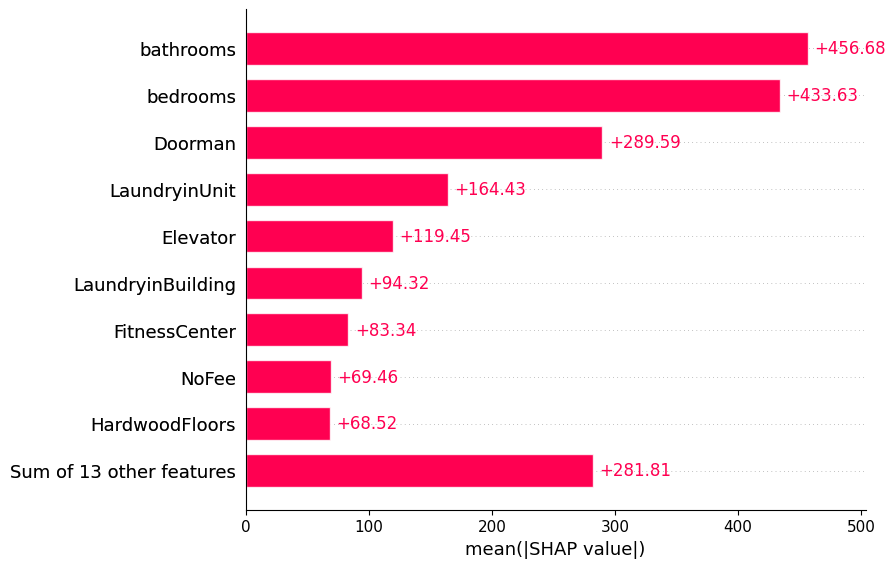

In [77]:
shap.plots.bar(shap_values)

In [78]:
shap_top10_model, shap_top10_metrics = fit_lasso_on_features(top10_shap, model_name='Lasso - SHAP Топ-10')
shap_top10_metrics.round(4)

,model,part,MAE,RMSE,R2
0,Lasso - SHAP Топ-10,train,708.6099,1037.7010,0.5723
1,Lasso - SHAP Топ-10,validation,724.6362,1055.7783,0.5825
2,Lasso - SHAP Топ-10,test,727.6997,1050.0441,0.5653


**vi. Compare the quality of these methods for different aspects — speed, metrics and stability.**

In [79]:
feature_selection_metrics = pd.concat([lasso_base_metrics, lasso_top10_metrics, simple_top10_metrics, permutation_top10_metrics, shap_top10_metrics], ignore_index=True)
feature_selection_metrics.pivot_table(index='model',columns='part', values=['MAE', 'RMSE', 'R2']).round(4)

MAE                           R2          \
part                              test     train validation    test   train   
model                                                                         
Lasso - Permutation Топ-10    729.8384  707.2150   724.6728  0.5648  0.5733   
Lasso - SHAP Топ-10           727.6997  708.6099   724.6362  0.5653  0.5723   
Lasso - Топ-10 коэффициентов  729.3528  707.1742   726.8185  0.5646  0.5730   
Lasso - все признаки          723.2418  702.9539   718.9936  0.5708  0.5784   
Lasso - простой отбор         733.2585  712.1404   732.0387  0.5608  0.5689   

                                              RMSE                        
part                         validation       test      train validation  
model                                                                     
Lasso - Permutation Топ-10       0.5828  1050.7302  1036.4516  1055.4036  
Lasso - SHAP Топ-10              0.5825  1050.0441  1037.7010  1055.7783  
Lasso - Топ-10 коэффициентов     0.5807  1050.9460  1036.7553  1058.1222  
Lasso - все признаки             0.5883  1043.4209  1030.1755  1048.5029  
Lasso - простой отбор            0.5762  1055.4533  1041.7769  1063.7318

Теперь отдельно посмотрим только на финальный test. Меньше `MAE` и `RMSE` лучше, больше `R2` лучше

In [80]:
fs_test_comparison = (feature_selection_metrics[feature_selection_metrics['part'] == 'test'].drop(columns='part').sort_values('RMSE').reset_index(drop=True))
fs_test_comparison.round(4)

,model,MAE,RMSE,R2
0,Lasso - все признаки,723.2418,1043.4209,0.5708
1,Lasso - SHAP Топ-10,727.6997,1050.0441,0.5653
2,Lasso - Permutation Топ-10,729.8384,1050.7302,0.5648
3,Lasso - Топ-10 коэффициентов,729.3528,1050.9460,0.5646
4,Lasso - простой отбор,733.2585,1055.4533,0.5608


In [81]:
selection_times = pd.DataFrame({'method': ['Simple filter', 'Permutation Importance', 'SHAP'], 'time_sec': [simple_time, permutation_time, shap_time]}).sort_values('time_sec')
selection_times.round(4)

,method,time_sec
2,SHAP,0.2393
0,Simple filter,0.3298
1,Permutation Importance,0.7443


Наилучшее качество на test показала базовая модель `Lasso` на всех 22 признаках.
 
После сокращения набора до 10 признаков качество ухудшилось незначительно.
 
Лучший результат среди методов отбора показал `SHAP`.

По скорости самым быстрым оказался простой фильтр, затем SHAP. 
Основные важные признаки достаточно стабильны между методами:
`bathrooms`, `bedrooms`, `Doorman`, `LaundryinUnit`, `Elevator` и `FitnessCenter`
регулярно входят в число наиболее важных.
 
В целом сокращение числа признаков с 22 до 10 позволяет заметно упростить модель
при небольшой потере качества. Среди методов отбора наиболее удачным в данном эксперименте оказался SHAP
 

#### Задание 7. Hyperparameter optimization

Теперь подберем гиперпараметры `ElasticNet`:

- `alpha` - общая сила регуляризации
- `l1_ratio` - баланс между L1 и L2 регуляризацией

Сравним три подхода:

1. собственный `Grid Search`
2. собственный `Random Search`
3. `Optuna` с `TPESampler`

Для честного сравнения во всех трех случаях:

- модель обучается на train
- гиперпараметры выбираются по validation
- test не участвует в подборе
- после выбора параметров модель переобучается на `train + validation` и только затем оценивается на test

Источники:

- ElasticNet: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html
- Random Search, Bergstra & Bengio: https://www.jmlr.org/papers/v13/bergstra12a.html
- Optuna TPESampler: https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html

In [82]:
import optuna

**i. Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.**

Сначала реализуем `Grid Search`.

Он проверяет все заданные комбинации `alpha на l1_ratio`. Для каждой комбинации:

1. обучаем `ElasticNet` на train
2. считаем `RMSE` на validation
3. сохраняем параметры и качество
4. сортируем результаты по `RMSE`


In [83]:
def grid_search_elasticnet(X_train, y_train, X_valid, y_valid, alpha_values, l1_ratio_values):
    rows = []
    for alpha_value, l1_ratio_value in product(alpha_values, l1_ratio_values):
        model = ElasticNet(alpha=alpha_value, l1_ratio=l1_ratio_value, max_iter=20000, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        rows.append({'alpha': alpha_value, 'l1_ratio': l1_ratio_value, 'RMSE': np.sqrt(mean_squared_error(y_valid, pred))})
    return pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)

In [84]:
alpha_grid = np.logspace(-4,1,9)
l1_ratio_grid = [0.05, 0.10, 0.25, 0.50, 0.75, 0.9, 1]
grid_start = time.perf_counter()
grid_results = grid_search_elasticnet(X_train_scaled, y_train_fs, X_valid_scaled, y_valid_fs, alpha_grid, l1_ratio_grid)
grid_time = time.perf_counter()-grid_start

In [85]:
len(grid_results)

63

In [86]:
grid_time

4.667582741938531

In [87]:
grid_results.head(10).round(6)

,alpha,l1_ratio,RMSE
0,0.000100,1.00,1047.395433
1,0.000422,1.00,1047.395673
2,0.001778,1.00,1047.396688
3,0.007499,1.00,1047.400984
4,0.031623,1.00,1047.419401
5,0.133352,1.00,1047.502401
6,0.000100,0.90,1047.512503
7,0.000100,0.75,1047.712564
8,0.562341,1.00,1047.927022
9,0.000422,0.90,1047.975687


Теперь реализуем `Random Search`.

В отличие от Grid Search, он не проверяет всю сетку. Мы заранее задаем количество попыток `n_iter` и случайно выбираем точки из пространства параметров

Для `alpha` используем логарифмический масштаб, потому что сила регуляризации может отличаться на несколько порядков


In [88]:
def random_search_elasticnet(X_train, y_train, X_valid, y_valid, n_iter=20, random_state=21):
    rng = np.random.RandomState(random_state)
    rows = []
    for trial in range(1, n_iter + 1):
        alpha_value = 10**rng.uniform(-4,1)
        l1_ratio_value = rng.uniform(0.05,1)
        model = ElasticNet(alpha=alpha_value, l1_ratio=l1_ratio_value, max_iter=20000, random_state=random_state)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        rows.append({'trial': trial, 'alpha': alpha_value, 'l1_ratio': l1_ratio_value, 'RMSE': np.sqrt(mean_squared_error(y_valid, pred))})
    return pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)

In [89]:
random_start = time.perf_counter()
random_results = random_search_elasticnet(X_train_scaled, y_train_fs, X_valid_scaled, y_valid_fs, n_iter=20, random_state=RANDOM_STATE)
random_time = time.perf_counter()-random_start

In [90]:
len(random_results)

20

In [91]:
random_time

1.6692595561034977

In [92]:
random_results.head(10).round(6)

,trial,alpha,l1_ratio,RMSE
0,6,0.000223,0.874034,1047.756965
1,1,0.000175,0.324654,1049.510939
2,12,0.002256,0.861398,1055.214818
3,7,0.000464,0.219218,1056.892164
4,3,0.001071,0.098235,1078.596357
5,4,0.003246,0.680715,1081.021629
6,5,0.003472,0.604412,1091.756932
7,15,0.003115,0.319746,1111.374077
8,16,0.004326,0.487133,1113.629372
9,11,0.011056,0.727692,1129.242956


**ii. Find the best combination of model hyperparameters.**

Лучшие параметры это строка с минимальным `RMSE` на validation


In [93]:
best_grid_params = {'alpha': grid_results.loc[0, 'alpha'], 'l1_ratio': grid_results.loc[0, 'l1_ratio']}
best_random_params = {'alpha': random_results.loc[0, 'alpha'], 'l1_ratio': random_results.loc[0, 'l1_ratio']}

In [94]:
best_grid_params

{'alpha': np.float64(0.0001), 'l1_ratio': np.float64(1.0)}

In [95]:
best_random_params

{'alpha': np.float64(0.00022276900909740872),
 'l1_ratio': np.float64(0.874034259793434)}

**iii. Fit the resulting model.**

После выбора гиперпараметров объединяем `train + validation`, заново обучаем `MinMaxScaler` только на этих данных и переобучаем `ElasticNet`.

Только после этого оцениваем итоговую модель на test


In [96]:
X_train_valid_raw = pd.concat([X_train_fs, X_valid_fs], axis=0)
y_train_valid = pd.concat([y_train_fs, y_valid_fs], axis=0)

In [97]:
def fit_final_elasticnet(params, model_name):
    scaler = MinMaxScaler()
    X_train_valid_scaled = scaler.fit_transform(X_train_valid_raw)
    X_final_test_scaled = scaler.transform(X_test_fs)
    model = ElasticNet(alpha=float(params['alpha']), l1_ratio=float(params['l1_ratio']), max_iter=20000, random_state=RANDOM_STATE)
    model.fit(X_train_valid_scaled, y_train_valid)
    test_pred = model.predict(X_final_test_scaled)
    return {'model': model_name, 'alpha': float(params['alpha']), 'l1_ratio': float(params['l1_ratio']), **regression_metrics(y_test_fs, test_pred)}

In [98]:
grid_test_result = fit_final_elasticnet(best_grid_params,'ElasticNet - Grid Search')
random_test_result = fit_final_elasticnet(best_random_params, 'ElasticNet - Random Search')
pd.DataFrame([grid_test_result,  random_test_result]).round(4)

,model,alpha,l1_ratio,MAE,RMSE,R2
0,ElasticNet - Grid Search,0.0001,1.000,723.5352,1041.5311,0.5723
1,ElasticNet - Random Search,0.0002,0.874,723.7973,1041.8135,0.5721


**iv. Import optuna and configure the same experiment with ElasticNet.**

`Optuna` выбирает следующие параметры с учетом результатов предыдущих trials

In [99]:
def optuna_objective(trial):
    alpha_value = trial.suggest_float('alpha', 1e-4, 10, log=True)
    l1_ratio_value = trial.suggest_float('l1_ratio', 0.05, 1)
    model = ElasticNet(alpha=alpha_value, l1_ratio=l1_ratio_value, max_iter=20000, random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train_fs)
    pred = model.predict(X_valid_scaled)
    return np.sqrt(mean_squared_error(y_valid_fs, pred))

In [100]:
optuna_sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=5)
optuna_study = optuna.create_study(direction='minimize', sampler=optuna_sampler)
optuna_start = time.perf_counter()
optuna_study.optimize(optuna_objective, n_trials=20, show_progress_bar=False)
optuna_time = time.perf_counter()-optuna_start

[I 2026-08-08 20:35:41,796] A new study created in memory with name: no-name-6612009e-eb1a-4dca-a07d-4d4f6f1c5f62
[I 2026-08-08 20:35:42,042] Trial 0 finished with value: 1049.5109391883368 and parameters: {'alpha': 0.0001752364328661884, 'l1_ratio': 0.324654176800326}. Best is trial 0 with value: 1049.5109391883368.
[I 2026-08-08 20:35:42,077] Trial 1 finished with value: 1505.6271737461145 and parameters: {'alpha': 0.4025610332737181, 'l1_ratio': 0.07053543742015231}. Best is trial 0 with value: 1049.5109391883368.
[I 2026-08-08 20:35:42,212] Trial 2 finished with value: 1078.5963574721156 and parameters: {'alpha': 0.0010705669362001628, 'l1_ratio': 0.09823459386060795}. Best is trial 0 with value: 1049.5109391883368.
[I 2026-08-08 20:35:42,280] Trial 3 finished with value: 1081.0216293860383 and parameters: {'alpha': 0.003246081875811063, 'l1_ratio': 0.680714779893465}. Best is trial 0 with value: 1049.5109391883368.
[I 2026-08-08 20:35:42,385] Trial 4 finished with value: 1091.7569

In [101]:
optuna_study.best_params

{'alpha': 0.00010367078313088488, 'l1_ratio': 0.37018405546175304}

In [102]:
optuna_study.best_value

1048.3816476137965

In [103]:
optuna_time

3.4643185939639807

**v. Estimate metrics and compare approaches**

Сравним Grid Search / Random Search / Optuna

In [104]:
hpo_comparison = pd.DataFrame([
    ['Grid Search', len(grid_results), grid_time, grid_results.loc[0, 'RMSE']],
    ['Random Search', len(random_results), random_time, random_results.loc[0, 'RMSE']],
    ['Optuna', len(optuna_study.trials), optuna_time, optuna_study.best_value]
], columns=['method', 'operations', 'time_sec', 'RMSE'])

In [105]:
hpo_comparison.sort_values('RMSE').round(4)

,method,operations,time_sec,RMSE
0,Grid Search,63,4.6676,1047.3954
1,Random Search,20,1.6693,1047.7570
2,Optuna,20,3.4643,1048.3816


И финальная оценка Optuna на test

In [106]:
optuna_test_result = fit_final_elasticnet(optuna_study.best_params, 'ElasticNet - Optuna')
pd.DataFrame([grid_test_result,random_test_result,optuna_test_result]).sort_values('RMSE').round(4)

,model,alpha,l1_ratio,MAE,RMSE,R2
0,ElasticNet - Grid Search,0.0001,1.0000,723.5352,1041.5311,0.5723
1,ElasticNet - Random Search,0.0002,0.8740,723.7973,1041.8135,0.5721
2,ElasticNet - Optuna,0.0001,0.3702,724.2191,1042.3319,0.5717


В этом эксперименте Grid Search оказался лучшим по качеству, но потребовал больше проверок параметров.
Random Search позволил получить почти такое же качество с существенно меньшим числом запусков.
Optuna при 20 trials не превзошел Grid Search.

На test различия между тремя способами подбора параметров очень небольшие.
 
Лучший результат снова показал Grid Search
 
для данной задачи сложный метод оптимизации не дал существенного выигрыша,
пространство поиска содержит только два гиперпараметра, поэтому обычный Grid Search работает достаточно эффективно

**vi. Run optuna on one of the cross-validation schemes**

In [107]:
hpo_cv_data = pd.concat([fs_train, fs_valid]).reset_index(drop=True)
hpo_cv_splits = kfold_custom(hpo_cv_data, k=5)

In [108]:
def optuna_cv_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.05, 1)
    rmse = []
    for train_idx, valid_idx in hpo_cv_splits:
        train_fold = hpo_cv_data.iloc[train_idx]
        valid_fold = hpo_cv_data.iloc[valid_idx]
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(train_fold[feature_cols])
        X_valid = scaler.transform(valid_fold[feature_cols])
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=RANDOM_STATE)
        model.fit(X_train, train_fold['price'])
        pred = model.predict(X_valid)
        rmse.append(np.sqrt(mean_squared_error(valid_fold['price'], pred)))
    return np.mean(rmse)

In [109]:
cv_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cv_study.optimize(optuna_cv_objective, n_trials=20)

[I 2026-08-08 20:35:45,828] A new study created in memory with name: no-name-6fb6b753-39e7-4016-a4d7-14d1564702f7
[I 2026-08-08 20:35:46,649] Trial 0 finished with value: 1035.6877289867375 and parameters: {'alpha': 0.0001752364328661884, 'l1_ratio': 0.324654176800326}. Best is trial 0 with value: 1035.6877289867375.
[I 2026-08-08 20:35:46,941] Trial 1 finished with value: 1468.0795544242853 and parameters: {'alpha': 0.4025610332737181, 'l1_ratio': 0.07053543742015231}. Best is trial 0 with value: 1035.6877289867375.
[I 2026-08-08 20:35:48,015] Trial 2 finished with value: 1056.5568793192272 and parameters: {'alpha': 0.0010705669362001628, 'l1_ratio': 0.09823459386060795}. Best is trial 0 with value: 1035.6877289867375.
[I 2026-08-08 20:35:48,795] Trial 3 finished with value: 1058.3998093887853 and parameters: {'alpha': 0.003246081875811063, 'l1_ratio': 0.680714779893465}. Best is trial 0 with value: 1035.6877289867375.
[I 2026-08-08 20:35:49,448] Trial 4 finished with value: 1066.6489

In [110]:
cv_study.best_params

{'alpha': 0.00010229783854791958, 'l1_ratio': 0.8610498980078881}

In [111]:
cv_study.best_value

1034.6977414207101

In [112]:
optuna_cv_test_result = fit_final_elasticnet(cv_study.best_params, 'ElasticNet - Optuna + KFold')

In [113]:
pd.DataFrame([optuna_cv_test_result]).round(4)

,model,alpha,l1_ratio,MAE,RMSE,R2
0,ElasticNet - Optuna + KFold,0.0001,0.861,723.6644,1041.6616,0.5722


При использовании Optuna вместе с 5-fold KFold были выбраны параметры:
- `alpha примерно 0.0001`
- `l1_ratio примерно 0.861`

Результат практически совпадает с Grid Search
 
Использование кросс-валидации делает оценку гиперпараметров более устойчивой, так как параметры проверяются сразу на нескольких разбиениях данных, но требует больше вычислений